<a href="https://colab.research.google.com/github/Mirazahmed0997/pandas101/blob/main/scikit_learn_pipeline_multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.compose import ColumnTransformer



file= pd.read_csv('student_data.csv')

print(file.head(5))



         date gender   age address famsize   Pstatus  M_Edu  F_Edu    M_Job  \
0  29/04/2018      M  18.0   Rural     GT3  Together      3      2  At_home   
1  29/04/2018      F  19.0   Rural     LE3     Apart      0      4    Other   
2  29/04/2018      F  19.0   Rural     GT3  Together      0      3  Teacher   
3  29/04/2018      F  19.0   Rural     LE3     Apart      2      3  At_home   
4  29/04/2018      M  17.0   Rural     GT3  Together      1      1  At_home   

      F_Job relationship smoker  tuition_fee  time_friends  ssc_result  \
0    Farmer           No     No      71672.0             4        4.22   
1    Health          Yes     No      26085.0             5        3.47   
2  Services           No     No      40891.0             3        3.32   
3  Business           No     No      50600.0             2        4.57   
4    Farmer           No     No      62458.0             2        4.50   

   hsc_result  
0        3.72  
1        2.62  
2        2.56  
3        4.17  


In [193]:
file.shape
file.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
1265,29/04/2018,M,17.0,Rural,GT3,Apart,4,4,Services,Business,Yes,No,84367.0,4,3.93,3.18
1128,29/04/2018,M,18.0,Rural,GT3,Together,0,0,Teacher,Farmer,No,No,35352.0,3,3.56,2.86
972,29/04/2018,F,17.0,Urban,LE3,Together,3,4,At_home,Services,No,No,87163.0,2,3.47,3.16
1556,29/04/2018,F,17.0,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743.0,1,3.88,3.19
1639,29/04/2018,F,17.0,Rural,LE3,Together,2,4,Teacher,Teacher,Yes,No,71158.0,2,3.52,3.15
1932,29/04/2018,F,18.0,Rural,GT3,Together,1,1,At_home,Farmer,No,No,65547.0,5,3.94,3.19
1542,29/04/2018,F,19.0,Urban,LE3,Apart,2,4,Other,Health,No,No,106152.0,4,5.00,4.41
1814,29/04/2018,M,19.0,Urban,LE3,Together,1,0,Services,Business,No,No,108977.0,2,2.82,2.40
421,29/04/2018,F,17.0,Rural,GT3,Together,2,0,Health,Health,No,No,52952.0,3,3.41,3.05
522,29/04/2018,F,17.0,Urban,LE3,Together,2,3,Services,Services,No,No,90535.0,4,4.29,3.47


In [194]:
file.info()
file.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


,0
date,0
gender,0
age,35
address,35
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,35
F_Job,0


In [195]:
file.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [196]:
file.duplicated().sum()
file.drop_duplicates(inplace=True)

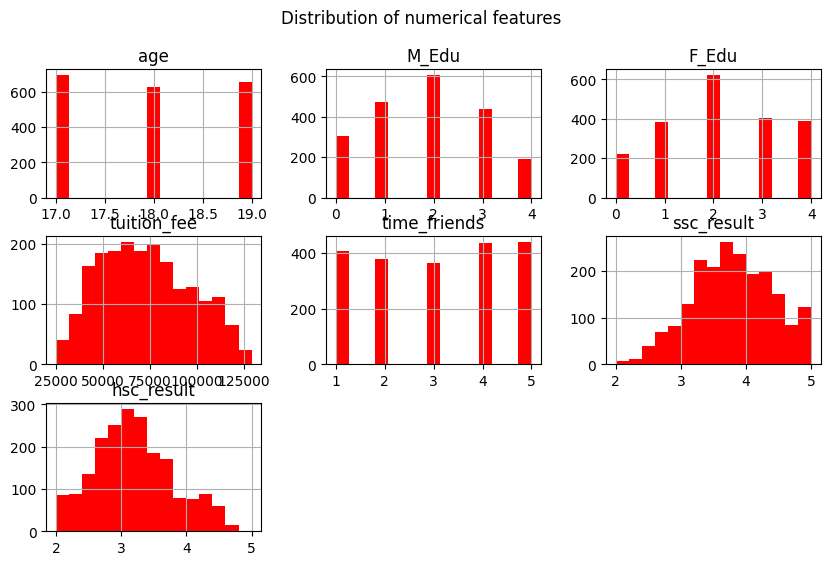

In [197]:
#EDA
file.hist(bins=15,figsize=(10,6),color='r')
plt.suptitle('Distribution of numerical features')
plt.show()

In [198]:
numerical_cols=['age','tuition_fee','ssc_result','hsc_result']
file[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


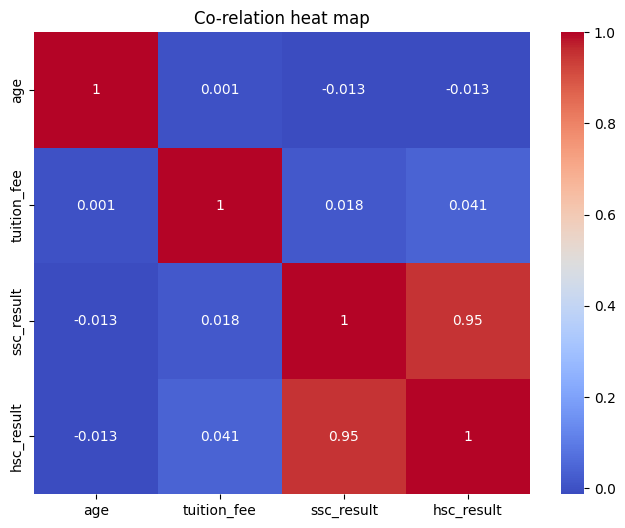

In [199]:
#co-relation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(file[numerical_cols].corr(),annot=True,cmap='coolwarm')
plt.title("Co-relation heat map")
plt.show()

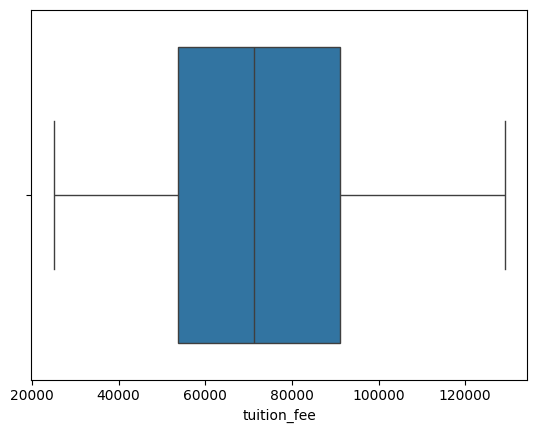

In [200]:
sns.boxplot(data=file,x='tuition_fee')
plt.show()
#

In [201]:
#scikit linear pipeline
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler


#categories
nominal_cat=['gender','address','famsize','Pstatus','relationship','smoker','F_Job','M_Job']
ordinal_cat=['M_Edu','F_Edu','time_friends']

M_edu_order=['0','1','2','3','4']
F_edu_order=['0','1','2','3','4']
time_friends_order=['5','4','3','2','1']

numerical_cols=['age','tuition_fee','ssc_result']

file.head(5)



,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18.0,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672.0,4,4.22,3.72
1,29/04/2018,F,19.0,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085.0,5,3.47,2.62
2,29/04/2018,F,19.0,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891.0,3,3.32,2.56
3,29/04/2018,F,19.0,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600.0,2,4.57,4.17
4,29/04/2018,M,17.0,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458.0,2,4.50,3.94


In [202]:
# 1st step :- simple imputation

numerical_transformer_pip=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

numerical_transformer_pip


Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

In [203]:

nominal_transformer_pip=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehotencoding',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

nominal_transformer_pip

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoding',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [204]:

# ordinal_transformer_pip=Pipeline(steps=[
#     ('imputer',SimpleImputer(strategy='most_frequent')),
#     ('encoder',OrdinalEncoder(categories=['time_friends_order','F_edu_order','M_edu_order'])),
#     ('scaler',MinMaxScaler())
# ])

# ordinal_transformer_pip

In [205]:
preprocessor=ColumnTransformer(
    transformers=[
        ('numerical',numerical_transformer_pip,numerical_cols),
        ('nominal',nominal_transformer_pip,nominal_cat),
        # ('ordinal',ordinal_transformer_pip,ordinal_cat)
    ],
    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tuition_fee', 'ssc_result']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'address', 'famsize', 'Pstatus',
                                  'relationship', 'smoker', 'F_Job',
                                  'M_Job'])])

In [206]:
x= file.drop(['date','hsc_result'],axis=1) #features
y=file['hsc_result'] #target col/feature

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

x_train.sample(5)
y_train.sample(5)

,hsc_result
1978,3.03
545,2.62
406,3.01
159,4.59
1174,4.03


#Linear regression




In [207]:
linear_pipe=Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model',LinearRegression())
    ]
)

linear_pipe.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', LinearRegression())])

In [208]:
linear_pipe.predict(x_test)
# x_test.head(5)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

In [209]:
sgd_pipeline= Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',SGDRegressor())
    ]
)

sgd_pipeline.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoding',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', SGDRegressor())])

In [210]:
sgd_pipeline.predict(x_test)


array([3.22343022, 3.77143804, 3.8271873 , 3.94409933, 3.84755686,
       3.33686548, 3.94826255, 2.51994224, 1.97591963, 3.28232537,
       3.67835631, 2.9304    , 3.24189161, 4.26983086, 3.06285757,
       2.64694561, 3.72291579, 3.40038504, 2.82902912, 2.94069842,
       2.83316458, 3.21733443, 2.96964906, 3.20175969, 1.91891248,
       2.51951703, 3.20907784, 3.83403123, 3.0684654 , 3.95024671,
       2.41146626, 3.95907997, 4.27938773, 2.58816949, 3.21952955,
       3.28388956, 2.76787005, 3.67094791, 2.50434341, 2.61492688,
       3.09796903, 2.98504839, 3.74456736, 2.77593462, 2.14002681,
       3.08692662, 2.64384151, 2.60782949, 3.99097937, 3.23802821,
       3.06713603, 3.45550562, 4.20018742, 3.62194743, 3.06253696,
       3.16321984, 3.30355717, 2.67357869, 3.81858019, 2.61765813,
       3.03080918, 2.77825222, 2.49251296, 4.44169649, 2.58627996,
       3.2192782 , 3.93628322, 2.68665579, 3.04664345, 3.21237728,
       3.03808074, 2.73706277, 2.61754394, 3.65154701, 3.08022

In [211]:
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error


In [215]:
#linear Regression
y_pred=linear_pipe.predict(x_test)



mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

print(f'MSE: {round(mean_squared_error(y_test,y_pred),4)}')
print(f'R2: {round(r2_score(y_test,y_pred),4)}')
print(f'RMSE: {round(root_mean_squared_error(y_test,y_pred),4)}')
print(f'MAE: {round(mean_absolute_error(y_test,y_pred),4)}')


MSE: 0.0203
R2: 0.9459
RMSE: 0.1425
MAE: 0.1114
